In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(2025)

# ---------------------------
# 1. 核心模型函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N = len(n); M = R.shape[1]
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        flows = n * g_i * R[:, j]
        num = np.sum(flows * p_A_res)
        den = np.sum(flows)
        tilde_p_A[j] = num / den if den > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    M_U = np.zeros(M); M_A = np.zeros(M)
    p_I = states[:, 2]
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for k in range(N):
            flow = n[k] * g_i[k] * R[k, j]
            prod_U *= np.power(1 - beta_U * p_I[k], flow)
            prod_A *= np.power(1 - beta_A * p_I[k], flow)
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    N = len(n)
    Q_U = np.zeros(N); Q_A = np.zeros(N)
    for i in range(N):
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * np.sum(R[i] * M_U)
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * np.sum(R[i] * M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = [states[:, i] for i in range(5)]
    new = np.zeros_like(states)
    new[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r
    new /= np.clip(new.sum(axis=1, keepdims=True), 1e-10, None)
    return new

def update_population(n, states, g_i, epsilon, R, T):
    N, M = R.shape
    X = states * n[:, None]
    F = n * g_i * epsilon
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 中转站流入
    m = np.zeros(M); m_X = np.zeros((M, 5))
    for j in range(M):
        flows = n * g_i * epsilon * R[:, j]
        m[j] = flows.sum()
        m_X[j] = (X * (g_i * epsilon)[:, None] * R[:, j][:, None]).sum(axis=0)

    # 返回
    flow_return = np.zeros(N); flow_return_X = np.zeros((N, 5))
    for j in range(M):
        flow_return += m[j] * T[:, j]
        flow_return_X += np.outer(T[:, j], m_X[j])

    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states

def main_simulation(Time, N, M, params):
    lambda1, mu1, mu2 = params['lambda1'], params['mu1'], params['mu2']
    beta_U, beta_A = params['beta_U'], params['beta_A']
    g_i = np.full(N, params['theta'] * params['g'])
    n = np.arange(30, 30 + 60 * N, 60, dtype=int)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99; states[:, 2] = 0.01
    states /= states.sum(axis=1, keepdims=True)

    # 随机网络
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)
    T = w / w.sum(axis=0, keepdims=True)

    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))

    for t in range(Time):
        state_history[t], pop_history[t] = states, n.copy()
        epsilon = compute_epsilon(states, params['alpha'], params['epsilon0'])
        n, states = update_population(n, states, g_i, epsilon, R, T)
        tilde_p_A = compute_effective_awareness(n, states, g_i, R)
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        N_U, N_A = compute_infection_residence(n, states, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n, states, g_i, R, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A)
        states = update_states(states, r, Q_U, Q_A, mu1, mu2)

    return state_history, pop_history




In [ ]:
# ---------------------------
# 2. 重新设计实验：λ₁ 扫描，重复 20 次
# ---------------------------
Time = 140
N, M = 15, 5
epsilon_list = [0.3, 0.9]
alpha_list = [0.3, 0.6]
lambda_values = np.linspace(0.4, 0.802, 201)
num_sims = 100

base_params = {
    'mu1': 0.15, 'mu2': 0.2,
    'beta_U': 0.003, 'beta_A': 0.0015,
    'g': 0.5, 'theta': 1
}

# Storage for results
results = {}  # key: (eps, alpha), value: mean peaks vs lambda

# Run experiments
for alpha in alpha_list:
    for eps in epsilon_list:
        mean_peaks = []
        for lam in tqdm(lambda_values, desc=f"α={alpha}, ε={eps}"):
            peaks = []
            for _ in range(num_sims):
                params = base_params.copy()
                params.update({'alpha': alpha, 'epsilon0': eps, 'lambda1': lam})
                hist, pop = main_simulation(Time, N, M, params)
                ai_t = [
                    np.sum(hist[t] * pop[t][:,None], axis=0)[2] / pop[t].sum()
                    for t in range(Time)
                ]
                peaks.append(max(ai_t))
            mean_peaks.append(np.mean(peaks))
        results[(alpha, eps)] = mean_peaks




α=0.6, ε=0.9: 100%|██████████| 201/201 [18:41<00:00,  5.58s/it]


In [ ]:
import pandas as pd

print(results)
# print(results.keys()) 

col_names = [rf'$\alpha$ = {alpha}, $\epsilon_0$ = {epsilon0}' for (alpha, epsilon0) in results.keys() ]
col_names_copy = [f'$\\alpha$ = {alpha}, $\epsilon_0$ = {epsilon0}' for (alpha, epsilon0) in results.keys() ]
print(col_names)
print(col_names_copy)
'''
col_names:
['$\\alpha$ = 0.3, $\\epsilon_0$ = 0.3',
 '$\\alpha$ = 0.3, $\\epsilon_0$ = 0.9',
 '$\\alpha$ = 0.6, $\\epsilon_0$ = 0.3',
 '$\\alpha$ = 0.6, $\\epsilon_0$ = 0.9']
'''

df = pd.DataFrame(
    data = {
        col : results[comb]
        for col, comb in zip(col_names, results.keys())
    },
    index= lambda_values
)
df.index.name = 'lambda'

# print(df)
df.to_csv('exp2_60_alpha03_06.csv')


{(0.3, 0.3): [0.5060254818594182, 0.5056882207763207, 0.5055232892616474, 0.5057207316221469, 0.5048435879425215, 0.5044433791385677, 0.504139467347664, 0.5040097991734465, 0.504067781155715, 0.5030587921785367, 0.5033528940120676, 0.5033289424069268, 0.5017039241600961, 0.5022941633504616, 0.5014448179109582, 0.5016458553913735, 0.5016495405953829, 0.5013845259953356, 0.5010172180870268, 0.5010929021392764, 0.5000743535401065, 0.5003307294149291, 0.49940960551519514, 0.4998006698161885, 0.4985242103241403, 0.49844199252361604, 0.49803521708700466, 0.4979490845661016, 0.4973393939747066, 0.4975256664593083, 0.4971803612728883, 0.4969874753587996, 0.49651413111600357, 0.49649145958806734, 0.49605667348213545, 0.4960425204616725, 0.4956067501680743, 0.4946241745659092, 0.4946594937380079, 0.4942366161051912, 0.4938849530860663, 0.49387923881137946, 0.49333866567737333, 0.4931126557064349, 0.4924997301758105, 0.4927908427730434, 0.4920290023385156, 0.49189565961159576, 0.4917946042924213,

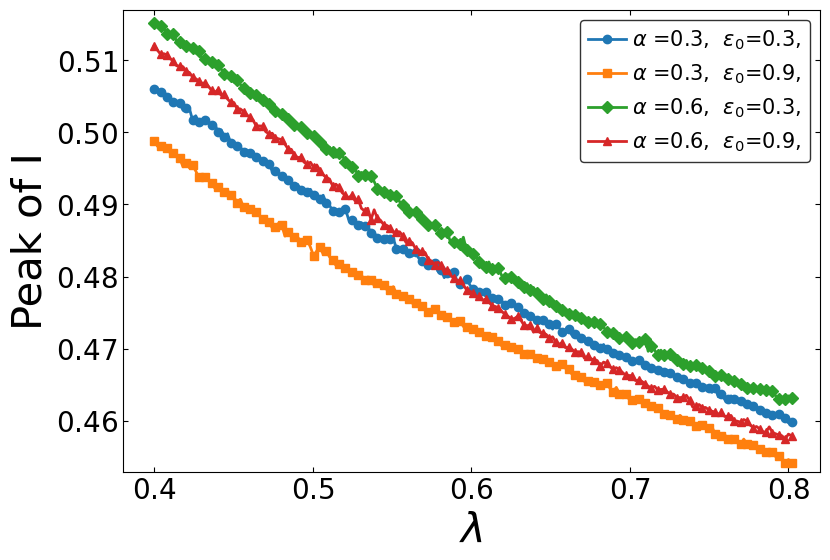

In [ ]:
# 绘图
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd


plt.figure(figsize=(9, 6))
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']  # enough markers
for (i, ((alpha, eps), peaks)) in enumerate(results.items()):
    plt.plot(lambda_values, peaks,
             label=rf'$\alpha$ ={alpha}, $\ \epsilon_0$={eps},',
             marker=markers[i % len(markers)],
             markevery=2,
             linewidth=2)
    
    
legend = plt.legend(
    loc='upper right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    borderpad=0.4,          # 图例内边距
    handlelength=1.8,    # 统一图标宽度
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
    
# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)

plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.4, 0.5, 0.6, 0.7,0.8],[ r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$', r'$0.8$'], fontsize=20)
plt.xlim(0.38, 0.82)

plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.46, 0.47,0.48, 0.49, 0.5, 0.51],[  r'$0.46$', r'$0.47$', r'$0.48$', r'$0.49$', r'$0.50$', r'$0.51$'],fontsize=20)
plt.ylim(0.453, 0.517)

plt.show()
